# Action Rules with Confidence Intervals — UCI Bank Marketing Dataset

Bank telemarketing campaigns contact existing clients to subscribe to a term deposit. The outcome is binary: the client subscribes (`yes`) or does not (`no`). Understanding *what to change* to increase subscription rates — and being able to **quantify the uncertainty** of those recommendations — is exactly what action rules with confidence intervals are built for.

This notebook demonstrates the full workflow on the **UCI Bank Marketing** dataset (41,188 calls, 21 attributes), covering:

1. **Dataset download and preprocessing** — discretize numerics, drop leaky and macroeconomic columns
2. **Mining action rules** — discover actionable recommendations with utility tables
3. **Three CI methods**: Bootstrap, Analytic (Wald), and Bayesian credible intervals
4. **Visualization**: bootstrap histograms, posterior plots, forest plots, grouped comparisons
5. **Rule categorization**: Accept, Reject, or Uncertain based on a statistical threshold
6. **Utility-aware analysis**: confidence intervals for realistic monetary gain
7. **Method comparison**: side-by-side diagnostic of all three approaches

**Requirements**: `pip install action-rules[viz]` (adds scipy + matplotlib)

**Reference**: Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems*, 62, 22–31.

## 1. Setup and Data Loading

The UCI Bank Marketing dataset is freely available from the UCI ML Repository. We download and extract it programmatically, then inspect its structure. The dataset records outbound phone calls from a Portuguese bank between May 2008 and November 2010.

**Target variable**: `y` — whether the client subscribed to a term deposit (`yes` / `no`). The base rate of subscription is roughly 11%, making this a moderately imbalanced classification problem and a realistic test bed for action rules.

In [1]:
import os
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

In [2]:
# Paths — all relative to the notebook location
DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "bank-additional.zip")
CSV_PATH = os.path.join(DATA_DIR, "bank_marketing.csv")

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

if not os.path.exists(CSV_PATH):
    # Download the zip archive if not already present
    if not os.path.exists(ZIP_PATH):
        print("Downloading Bank Marketing dataset from UCI ML Repository...")
        try:
            urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
            print(f"  Saved to: {ZIP_PATH}")
        except Exception as e:
            print(
                f"  Download failed: {e}\n"
                f"  Please download the file manually from:\n"
                f"    {UCI_URL}\n"
                f"  and place the zip at: {ZIP_PATH}"
            )
            raise

    # Extract bank-additional-full.csv from the zip
    print("Extracting CSV...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        inner_path = "bank-additional/bank-additional-full.csv"
        with zf.open(inner_path) as src, open(CSV_PATH, "wb") as dst:
            dst.write(src.read())
    print(f"  Saved to: {CSV_PATH}")
else:
    print(f"Dataset already present at: {CSV_PATH}")

# Load the raw dataset
raw = pd.read_csv(CSV_PATH, sep=";")
print(f"\nShape: {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head(3)

Dataset already present at: data\bank_marketing.csv

Shape: 41188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Class distribution of the target variable
dist = raw["y"].value_counts()
print("Target distribution (y):")
for val, count in dist.items():
    print(f"  {val:>4}: {count:>6,}  ({count / len(raw) * 100:.1f}%)")

Target distribution (y):
    no: 36,548  (88.7%)
   yes:  4,640  (11.3%)


## 2. Preprocessing

Before mining, we apply the following transformations:

1. **Drop `duration`** — this column records the last contact duration in seconds. It is known to be highly predictive of `y` but constitutes data leakage: its value is not known before the call is made. The UCI authors explicitly recommend dropping it for realistic predictive models.

2. **Drop macroeconomic columns** — `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` are aggregate economic indicators that vary by period, not by individual client. They are not actionable at the campaign level.

3. **Discretize numeric columns** — the action rules algorithm requires categorical attributes. We bin `age`, `campaign`, `pdays`, and `previous` into interpretable ordinal categories.

4. **Keep string columns as-is** — `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, and `poutcome` are already categorical.

In [4]:
data = raw.copy()

# 1. Drop leaky column
data = data.drop(columns=["duration"])

# 2. Drop macroeconomic columns (not actionable at the individual level)
macro_cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
data = data.drop(columns=macro_cols)

# 3. Discretize numeric columns into interpretable categories

# Age: young (<30), middle (30-55), senior (55+)
def discretize_age(age):
    if age < 30:
        return "young"
    elif age <= 55:
        return "middle"
    else:
        return "senior"

# Campaign: number of contacts during this campaign
def discretize_campaign(n):
    if n <= 2:
        return "low"
    elif n <= 5:
        return "moderate"
    else:
        return "high"

# Pdays: 999 means client was never contacted before this campaign
def discretize_pdays(d):
    if d == 999:
        return "never"
    elif d <= 14:
        return "recent"
    else:
        return "old"

# Previous: number of contacts before this campaign
def discretize_previous(p):
    if p == 0:
        return "none"
    elif p <= 2:
        return "few"
    else:
        return "many"

data["age"] = data["age"].apply(discretize_age)
data["campaign"] = data["campaign"].apply(discretize_campaign)
data["pdays"] = data["pdays"].apply(discretize_pdays)
data["previous"] = data["previous"].apply(discretize_previous)

print(f"Preprocessed dataset: {data.shape[0]} rows x {data.shape[1]} columns")
print(f"Columns: {list(data.columns)}")
data.head(5)

Preprocessed dataset: 41188 rows x 15 columns
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,senior,housemaid,married,basic.4y,no,no,no,telephone,may,mon,low,never,none,nonexistent,no
1,senior,services,married,high.school,unknown,no,no,telephone,may,mon,low,never,none,nonexistent,no
2,middle,services,married,high.school,no,yes,no,telephone,may,mon,low,never,none,nonexistent,no
3,middle,admin.,married,basic.6y,no,no,no,telephone,may,mon,low,never,none,nonexistent,no
4,senior,services,married,high.school,no,no,yes,telephone,may,mon,low,never,none,nonexistent,no


In [5]:
# Verify discretization — check value distributions for the binned columns
for col in ["age", "campaign", "pdays", "previous"]:
    counts = data[col].value_counts().to_dict()
    print(f"  {col}: {counts}")

  age: {'middle': 31937, 'young': 5669, 'senior': 3582}
  campaign: {'low': 28212, 'moderate': 9591, 'high': 3385}
  pdays: {'never': 39673, 'recent': 1453, 'old': 62}
  previous: {'none': 35563, 'few': 5315, 'many': 310}


## 3. Mining Action Rules

We define two types of attributes:

- **Stable attributes** — characteristics of the client that do not change between the undesired and desired state: `age`, `marital`, `job`, `education`. These form the *preconditions* of each rule.
- **Flexible attributes** — campaign-level decisions the bank can control: `contact` (channel), `poutcome` (outcome of previous campaign), `campaign` (number of contacts), `pdays` (recency of previous contact). These define the *action*.

The target is `y` — we want rules that move clients from `no` (did not subscribe) to `yes` (subscribed).

We also attach **utility tables** to quantify the economic value of each state transition. A term deposit subscription is worth €500 in expected revenue; different contact channels and campaign intensities carry different costs.

In [6]:
from action_rules import ActionRules

# Stable attributes: client demographics that do not change
stable_attributes = ["age", "marital", "job", "education"]

# Flexible attributes: campaign decisions the bank can control
flexible_attributes = ["contact", "poutcome", "campaign", "pdays"]

# Intrinsic utility: how much is each state worth?
intrinsic_utility_table = {
    ("y", "yes"): 500.0,          # Expected revenue from a term deposit subscription
    ("y", "no"): 0.0,
    ("contact", "cellular"): -2.0,    # Cost of mobile outreach
    ("contact", "telephone"): -5.0,   # Cost of landline outreach
    ("campaign", "low"): -10.0,       # Cost for 1–2 contact attempts
    ("campaign", "moderate"): -25.0,  # Cost for 3–5 contact attempts
    ("campaign", "high"): -50.0,      # Cost for 6+ contact attempts
}

# Transition utility: cost or benefit of changing an attribute value
transition_utility_table = {
    ("contact", "telephone", "cellular"): -1.0,    # Switching from landline to mobile
    ("campaign", "high", "low"): 20.0,              # Reducing from 6+ to 1–2 contacts saves effort
    ("campaign", "moderate", "low"): 10.0,          # Reducing from 3–5 to 1–2 contacts saves effort
}

# Initialize the miner
ar = ActionRules(
    min_stable_attributes=2,
    min_flexible_attributes=1,
    min_undesired_support=200,
    min_desired_support=200,
    min_undesired_confidence=0.65,
    min_desired_confidence=0.65,
    verbose=False,
    intrinsic_utility_table=intrinsic_utility_table,
    transition_utility_table=transition_utility_table,
)

ar.fit(
    data=data,
    stable_attributes=stable_attributes,
    flexible_attributes=flexible_attributes,
    target="y",
    target_undesired_state="no",
    target_desired_state="yes",
    use_sparse_matrix=True,
)

rules = ar.get_rules()
n_rules = len(rules.action_rules)
print(f"Mined {n_rules} action rules")

Mined 16 action rules


In [7]:
# Preview the first few rules in human-readable notation
for i, rule_text in enumerate(rules.get_pretty_ar_notation()[:5]):
    print(f"Rule {i}: {rule_text}\n")

Rule 0: If attribute 'age' is 'middle', attribute 'education' is 'university.degree', attribute 'poutcome' value 'failure' is changed to 'success', then 'y' value 'no' is changed to 'yes with support: 238, confidence: 0.5752184434192802, uplift: 0.012217828499269693, support of undesired part: 811, confidence of undesired part: 0.8483263598326359, support of desired part: 238, confidence of desired part: 0.6780626780626781, max_rule_gain: 500.0, realistic_rule_gain: 263.194518947657, realistic_dataset_gain: 251613.96011396009.

Rule 1: If attribute 'age' is 'middle', attribute 'education' is 'university.degree', attribute 'poutcome' value 'nonexistent' is changed to 'success', then 'y' value 'no' is changed to 'yes with support: 238, confidence: 0.6112285431281848, uplift: 0.11776208156221753, support of undesired part: 7545, confidence of undesired part: 0.9014336917562724, support of desired part: 238, confidence of desired part: 0.6780626780626781, max_rule_gain: 500.0, realistic_ru

## 4. Confidence Intervals — Overview

A point estimate such as "uplift = 0.012" reveals nothing about statistical uncertainty. With 41,188 rows the sample is large, but individual rules may apply to much smaller subgroups. A confidence interval gives the range of plausible true values at a given confidence level.

The `action-rules` package implements three complementary methods:

| Method | Mechanism | Strengths | Weaknesses |
|--------|-----------|-----------|------------|
| **Bootstrap** | Resample dataset B times, compute statistic on each resample, take percentile interval | Non-parametric, no distributional assumption | Slower; requires B resamples |
| **Analytic (Wald)** | Delta method propagates variance of two binomial proportions through the uplift formula | Instantaneous; closed-form | Assumes large-sample normality; may underestimate uncertainty for sparse rules |
| **Bayesian** | Beta–Binomial conjugate model; Monte Carlo posterior sampling | Full posterior; direct probabilistic interpretation; robust for small groups | Requires prior specification; MC variance for very small N |

All three methods compute intervals for both **uplift** and **realistic rule gain** (utility-weighted).

## 5. Bootstrap Confidence Intervals

The bootstrap is the most widely applicable non-parametric method. We resample the full dataset with replacement 500 times, compute the uplift for each rule on every resample, and use the 2.5th and 97.5th percentiles of the resulting distribution as the 95% CI.

500 resamples is sufficient for exploratory analysis. For publication-quality results, 1000–2000 resamples are recommended.

In [8]:
%%time

results_boot = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'SE':>10}")
print("-" * 62)
for r in results_boot:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | "
        f"{r.uplift_se:>10.6f}"
    )

  Rule |     Uplift |                     95% CI |         SE
--------------------------------------------------------------
     0 |   0.012266 | [  0.010821,   0.013812] |   0.000761
     1 |   0.117663 | [  0.106686,   0.128542] |   0.005203
     2 |   0.129451 | [  0.118618,   0.140743] |   0.005595
     3 |   0.011420 | [  0.009900,   0.013032] |   0.000724
     4 |   0.077311 | [  0.070235,   0.084004] |   0.003558
     5 |   0.041275 | [  0.037566,   0.045333] |   0.002040
     6 |   0.088702 | [  0.080820,   0.096890] |   0.004214
     7 |   0.042020 | [  0.037930,   0.046028] |   0.002016
     8 |   0.012185 | [  0.010685,   0.013655] |   0.000772
     9 |   0.118492 | [  0.107755,   0.128308] |   0.005405
    10 |   0.012337 | [  0.011031,   0.013811] |   0.000704
    11 |   0.087516 | [  0.078659,   0.096174] |   0.004352
    12 |   0.031782 | [  0.028552,   0.034873] |   0.001625
    13 |   0.011412 | [  0.010089,   0.012685] |   0.000690
    14 |   0.077980 | [  0.071117, 

## 6. Analytic (Wald) Confidence Intervals

The analytic method applies the **delta method** to propagate the variance of two independent binomial proportions — undesired-side confidence and desired-side confidence — through the uplift formula. It is computationally negligible (no resampling) and serves as a useful baseline.

Note that the Wald approximation assumes the normal distribution is a reasonable approximation to the sampling distribution of the proportions. For rules with small support (say, fewer than 30 observations per side), the bootstrap or Bayesian interval is more reliable.

In [9]:
%%time

results_anal = ar.confidence_intervals(
    data,
    method="analytic",
    confidence_level=0.95,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'SE':>10}")
print("-" * 62)
for r in results_anal:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | "
        f"{r.uplift_se:>10.6f}"
    )

  Rule |     Uplift |                     95% CI |         SE
--------------------------------------------------------------
     0 |   0.012218 | [  0.010967,   0.013469] |   0.000638
     1 |   0.117762 | [  0.107745,   0.127779] |   0.005111
     2 |   0.129377 | [  0.118479,   0.140275] |   0.005560
     3 |   0.011377 | [  0.010180,   0.012575] |   0.000611
     4 |   0.077285 | [  0.070232,   0.084339] |   0.003599
     5 |   0.041297 | [  0.037903,   0.044692] |   0.001732
     6 |   0.088509 | [  0.080539,   0.096479] |   0.004066
     7 |   0.042176 | [  0.038753,   0.045599] |   0.001746
     8 |   0.012230 | [  0.011015,   0.013445] |   0.000620
     9 |   0.118606 | [  0.108509,   0.128703] |   0.005152
    10 |   0.012362 | [  0.011267,   0.013456] |   0.000558
    11 |   0.087460 | [  0.079376,   0.095543] |   0.004124
    12 |   0.031783 | [  0.028871,   0.034695] |   0.001486
    13 |   0.011407 | [  0.010241,   0.012573] |   0.000595
    14 |   0.077918 | [  0.070805, 

## 7. Bayesian Credible Intervals

The Bayesian approach treats each group proportion as a random variable and places a **Beta(1, 1) prior** (uniform) on it. After observing the data, the posterior is Beta(1 + successes, 1 + failures). We draw 10,000 Monte Carlo samples from the joint posterior and compose them into an uplift distribution.

The resulting interval is a **credible interval**: there is a 95% posterior probability that the true uplift lies within it, conditional on the model and prior. This is a stronger statement than the frequentist CI, but it is model-dependent.

In [10]:
%%time

results_bayes = ar.confidence_intervals(
    data,
    method="bayesian",
    confidence_level=0.95,
    n_mc=10000,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% Credible Interval':>26} | {'SE':>10}")
print("-" * 62)
for r in results_bayes:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | "
        f"{r.uplift_se:>10.6f}"
    )

  Rule |     Uplift |      95% Credible Interval |         SE
--------------------------------------------------------------
     0 |   0.012186 | [  0.010913,   0.013424] |   0.000637
     1 |   0.117549 | [  0.107343,   0.127430] |   0.005115
     2 |   0.129178 | [  0.118346,   0.139743] |   0.005448
     3 |   0.011332 | [  0.010122,   0.012529] |   0.000616
     4 |   0.077125 | [  0.069906,   0.084066] |   0.003599
     5 |   0.041190 | [  0.037744,   0.044503] |   0.001720
     6 |   0.088292 | [  0.080338,   0.096077] |   0.004026
     7 |   0.042091 | [  0.038572,   0.045412] |   0.001739
     8 |   0.012183 | [  0.010954,   0.013366] |   0.000616
     9 |   0.118358 | [  0.108260,   0.128302] |   0.005127
    10 |   0.012314 | [  0.011205,   0.013389] |   0.000564
    11 |   0.087269 | [  0.078985,   0.095057] |   0.004117
    12 |   0.031691 | [  0.028759,   0.034526] |   0.001488
    13 |   0.011369 | [  0.010202,   0.012529] |   0.000592
    14 |   0.077716 | [  0.070420, 

## 8. Visualization

The `action_rules.visualization` module provides four plot types for communicating uncertainty in action rules. All functions return a `matplotlib.figure.Figure` and accept an optional `ax` parameter for embedding in larger layouts.

In [11]:
from action_rules.visualization import bootstrap_histogram, posterior_plot, forest_plot, grouped_forest_plot

### 8.1 Bootstrap Histogram (Single Rule)

The bootstrap histogram shows the empirical sampling distribution of the uplift statistic for a single rule across all 500 resamples. The shaded region marks the 95% CI. A bell-shaped distribution indicates that the normal approximation (analytic method) is appropriate for this rule; a skewed or multimodal distribution warrants using bootstrap or Bayesian intervals instead.

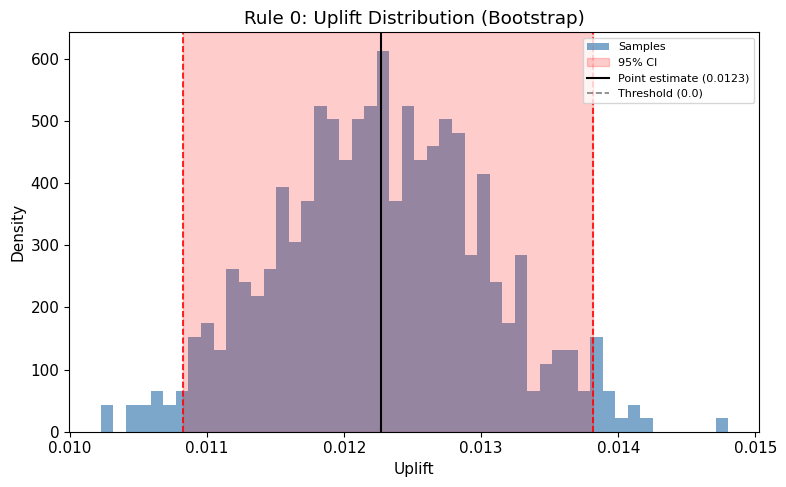

In [12]:
# Bootstrap sampling distribution for the first mined rule
fig = bootstrap_histogram(results_boot[0], metric="uplift", threshold=0.0)
plt.tight_layout()

### 8.2 Posterior Plot (Bayesian, Single Rule)

The Bayesian posterior plot shows the kernel density estimate of the Monte Carlo uplift samples drawn from the Beta–Binomial posterior. Unlike the bootstrap histogram (which characterises a sampling procedure), this curve directly represents the posterior probability density over the true uplift value given the observed data.

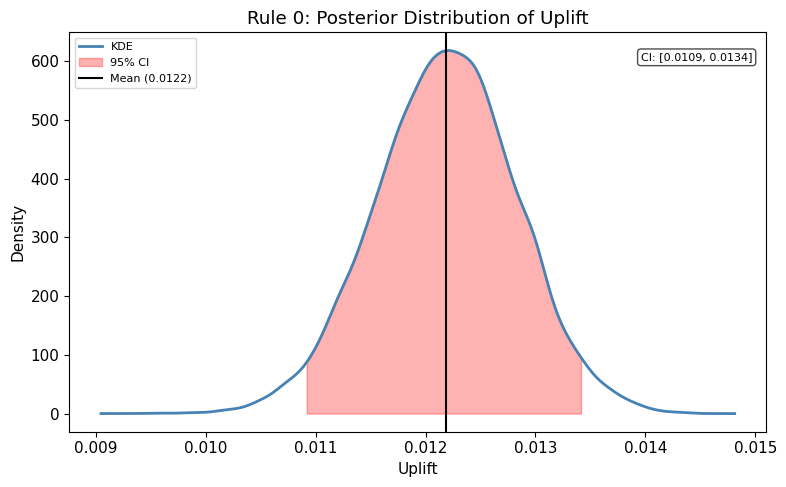

In [13]:
# Posterior distribution of uplift for the first rule
fig = posterior_plot(results_bayes[0], metric="uplift")
plt.tight_layout()

### 8.3 Forest Plot — Bootstrap CIs (All Rules)

A forest plot is the standard visualization for displaying multiple effect sizes alongside their confidence intervals. Each row represents one action rule. The vertical dashed line at 0 is the decision threshold: rules whose entire CI lies to the right are classified as **Accept** (green); those entirely to the left as **Reject** (red); and those that straddle the threshold as **Uncertain** (orange).

Setting `show_categories=True` adds the Accept/Reject/Uncertain label to each row.

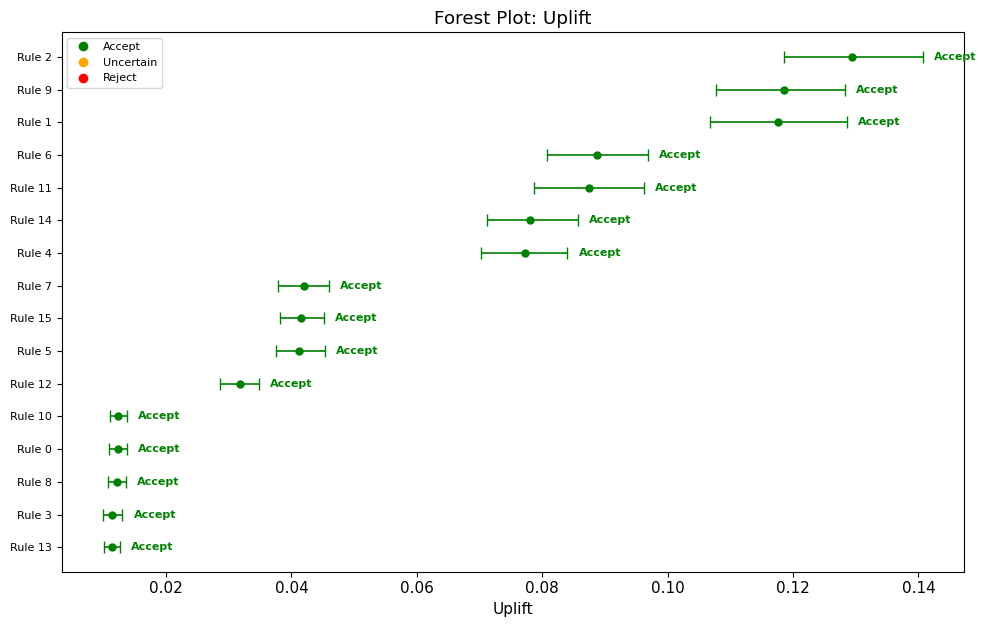

In [14]:
# Slice to first 20 rules if there are more than 30 to keep the plot readable
boot_slice = results_boot[:20] if len(results_boot) > 30 else results_boot

fig = forest_plot(boot_slice, metric="uplift", threshold=0.0, show_categories=True)
plt.tight_layout()

### 8.4 Grouped Forest Plot — All Three Methods

The grouped forest plot overlays bootstrap, analytic, and Bayesian intervals for each rule on the same axes. This is a diagnostic tool: when all three methods agree, the intervals are robust. Discrepancies — especially wide bootstrap intervals with narrow analytic ones — indicate that the sample size for that rule is too small for the normal approximation to hold reliably.

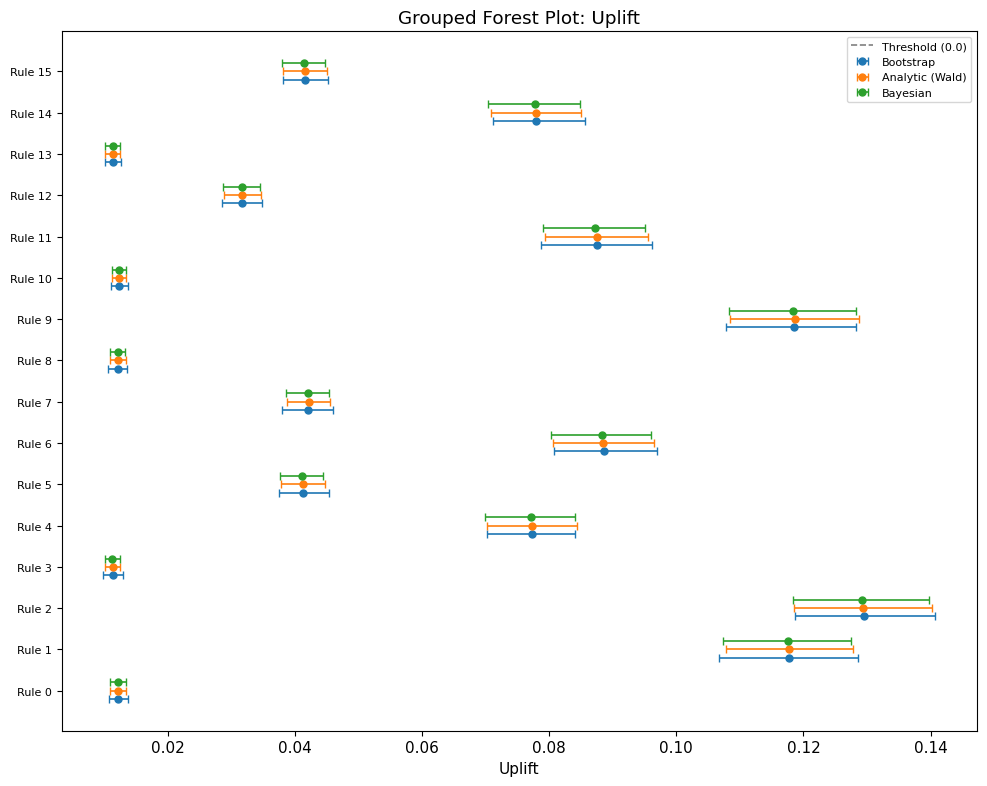

In [15]:
# Align slices across all three methods for consistent comparison
anal_slice = results_anal[:20] if len(results_anal) > 30 else results_anal
bayes_slice = results_bayes[:20] if len(results_bayes) > 30 else results_bayes

fig = grouped_forest_plot(
    {"Bootstrap": boot_slice, "Analytic (Wald)": anal_slice, "Bayesian": bayes_slice},
    metric="uplift",
    threshold=0.0,
)
plt.tight_layout()

## 9. Rule Categorization: Accept, Reject, or Uncertain

Confidence intervals enable principled, threshold-based decision making. Given a threshold τ (here τ = 0), each rule is classified as:

- **Accept** — the entire 95% CI lies above τ: the rule has statistically significant positive uplift and should be deployed.
- **Reject** — the entire 95% CI lies below τ: the rule is not effective and should be discarded.
- **Uncertain** — the CI overlaps τ: the evidence is inconclusive. More data or a different design is needed.

This three-valued verdict is more informative than a binary p-value because it explicitly represents the ambiguous middle ground where p ≈ α.

In [16]:
# Bootstrap CIs with threshold-based categorization
results_cat = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="uplift",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'Category':>12}")
print("-" * 68)
for r in results_cat:
    cat = r.category.value if r.category else "N/A"
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | "
        f"{cat:>12}"
    )

  Rule |     Uplift |                     95% CI |     Category
--------------------------------------------------------------------
     0 |   0.012266 | [  0.010821,   0.013812] |       accept
     1 |   0.117663 | [  0.106686,   0.128542] |       accept
     2 |   0.129451 | [  0.118618,   0.140743] |       accept
     3 |   0.011420 | [  0.009900,   0.013032] |       accept
     4 |   0.077311 | [  0.070235,   0.084004] |       accept
     5 |   0.041275 | [  0.037566,   0.045333] |       accept
     6 |   0.088702 | [  0.080820,   0.096890] |       accept
     7 |   0.042020 | [  0.037930,   0.046028] |       accept
     8 |   0.012185 | [  0.010685,   0.013655] |       accept
     9 |   0.118492 | [  0.107755,   0.128308] |       accept
    10 |   0.012337 | [  0.011031,   0.013811] |       accept
    11 |   0.087516 | [  0.078659,   0.096174] |       accept
    12 |   0.031782 | [  0.028552,   0.034873] |       accept
    13 |   0.011412 | [  0.010089,   0.012685] |       accept

In [17]:
# Summarise category counts
from collections import Counter

category_counts = Counter(
    r.category.value for r in results_cat if r.category is not None
)
print("Rule category summary (bootstrap, threshold=0, 95% CI):")
for cat, count in sorted(category_counts.items()):
    print(f"  {cat:>12}: {count}")

Rule category summary (bootstrap, threshold=0, 95% CI):
        accept: 16


## 10. Utility-Aware Analysis

Statistical uplift answers "does this rule increase subscription rates?" The **realistic rule gain** answers a more business-relevant question: "after accounting for the cost of the intervention and the expected revenue from subscriptions, does this rule generate positive net economic value?"

The formula for realistic rule gain combines:
- The **intrinsic utility** of being in each state (e.g., €500 for a subscription)
- The **transition utility** of changing attribute values (e.g., cost of switching contact channel)
- The **uplift** of the rule (how much more likely the client is to subscribe)
- The **support** (how many clients the rule covers)

A rule with positive uplift but negative realistic gain is not worth deploying: the intervention costs more than the expected return.

In [18]:
%%time

# Bootstrap CIs for realistic rule gain
results_gain = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="realistic_rule_gain",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Gain (EUR)':>12} | {'95% CI':>28} | {'Category':>12}")
print("-" * 72)
for r in results_gain:
    if r.realistic_rule_gain_point is not None:
        cat = r.category.value if r.category else "N/A"
        print(
            f"  {r.rule_index:>4} | {r.realistic_rule_gain_point:>12.2f} | "
            f"[{r.realistic_rule_gain_ci_lower:>12.2f}, {r.realistic_rule_gain_ci_upper:>12.2f}] | "
            f"{cat:>12}"
        )

  Rule |   Gain (EUR) |                       95% CI |     Category
------------------------------------------------------------------------
     0 |       264.31 | [      237.01,       289.61] |       accept
     1 |       289.57 | [      263.22,       314.89] |       accept
     2 |       287.01 | [      264.22,       311.78] |       accept
     3 |       267.26 | [      238.39,       296.72] |       accept
     4 |       281.83 | [      256.85,       303.34] |       accept
     5 |       314.77 | [      287.57,       341.78] |       accept
     6 |       280.75 | [      255.40,       306.13] |       accept
     7 |       312.23 | [      285.89,       339.84] |       accept
     8 |       271.03 | [      242.48,       298.99] |       accept
     9 |       291.23 | [      264.97,       315.81] |       accept
    10 |       371.12 | [      342.69,       398.13] |       accept
    11 |       288.00 | [      259.46,       315.11] |       accept
    12 |       319.39 | [      293.01,     

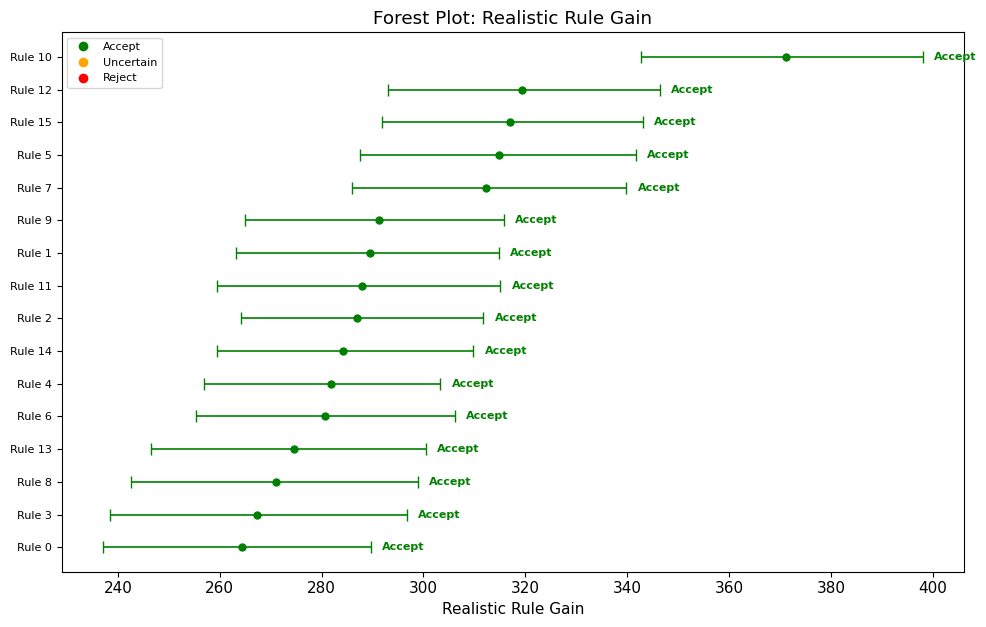

In [19]:
# Forest plot for realistic rule gain — which rules are economically worthwhile?
gain_slice = results_gain[:20] if len(results_gain) > 30 else results_gain

fig = forest_plot(gain_slice, metric="realistic_rule_gain", threshold=0.0, show_categories=True)
plt.tight_layout()

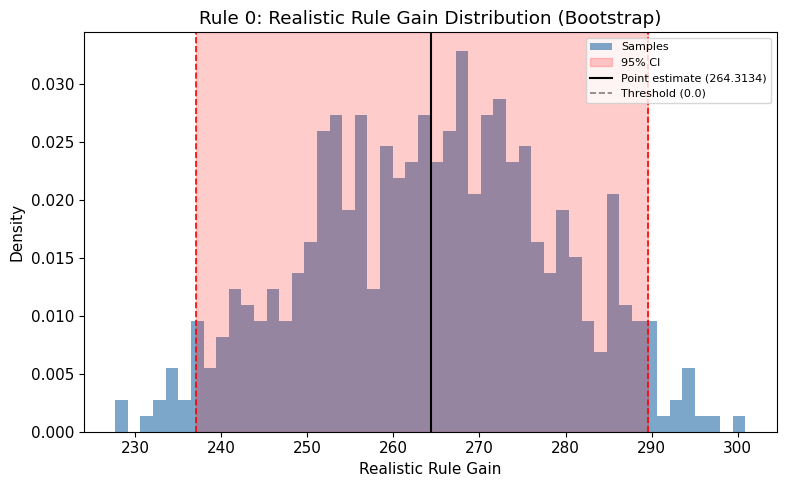

In [20]:
# Bootstrap distribution of realistic rule gain for the first rule
fig = bootstrap_histogram(results_gain[0], metric="realistic_rule_gain", threshold=0.0)
plt.tight_layout()

## 11. Method Comparison

Now that we have results from all three methods, we can compare them systematically. Two questions are of interest:

1. **Do the point estimates agree?** They should be nearly identical: all three methods estimate the same quantity from the same data.
2. **Do the interval widths agree?** Discrepancies reveal where the normal approximation (analytic) breaks down relative to the non-parametric (bootstrap) and model-based (Bayesian) alternatives.

The grouped forest plot on realistic rule gain gives an immediate visual answer.

In [21]:
%%time

# Compute realistic rule gain CIs with all three methods
gain_boot = ar.confidence_intervals(
    data, method="bootstrap", n_bootstrap=500, random_state=42
)
gain_anal = ar.confidence_intervals(
    data, method="analytic"
)
gain_bayes = ar.confidence_intervals(
    data, method="bayesian", n_mc=10000, random_state=42
)

CPU times: total: 3.45 s
Wall time: 3.45 s


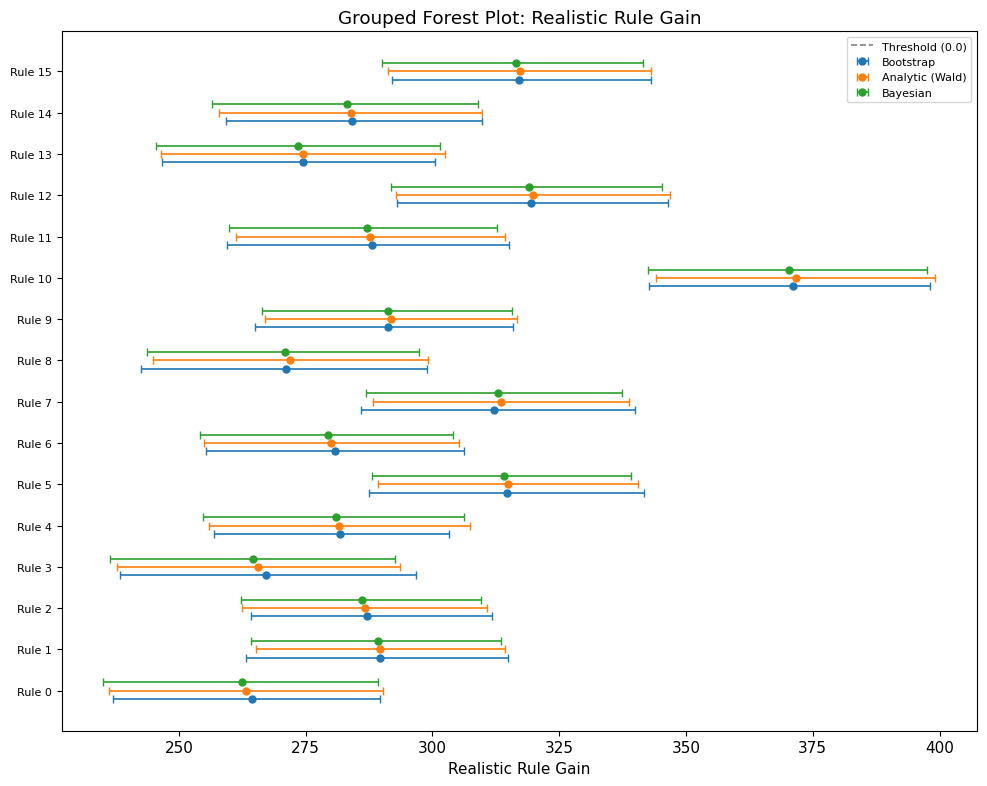

In [22]:
# Slice to first 20 rules if needed
gb_slice = gain_boot[:20] if len(gain_boot) > 30 else gain_boot
ga_slice = gain_anal[:20] if len(gain_anal) > 30 else gain_anal
gbay_slice = gain_bayes[:20] if len(gain_bayes) > 30 else gain_bayes

fig = grouped_forest_plot(
    {"Bootstrap": gb_slice, "Analytic (Wald)": ga_slice, "Bayesian": gbay_slice},
    metric="realistic_rule_gain",
    threshold=0.0,
)
plt.tight_layout()

In [23]:
# Build a side-by-side comparison DataFrame for all three methods
rows = []
for method_name, results in [
    ("Bootstrap", gain_boot),
    ("Analytic", gain_anal),
    ("Bayesian", gain_bayes),
]:
    for r in results:
        row = {
            "Rule": r.rule_index,
            "Method": method_name,
            "Uplift": round(r.uplift_point, 6),
            "Uplift CI Lower": round(r.uplift_ci_lower, 6),
            "Uplift CI Upper": round(r.uplift_ci_upper, 6),
            "Uplift CI Width": round(r.uplift_ci_upper - r.uplift_ci_lower, 6),
            "Uplift SE": round(r.uplift_se, 6),
        }
        if r.realistic_rule_gain_point is not None:
            row["Gain"] = round(r.realistic_rule_gain_point, 2)
            row["Gain CI Lower"] = round(r.realistic_rule_gain_ci_lower, 2)
            row["Gain CI Upper"] = round(r.realistic_rule_gain_ci_upper, 2)
            row["Gain CI Width"] = round(
                r.realistic_rule_gain_ci_upper - r.realistic_rule_gain_ci_lower, 2
            )
        rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values(["Rule", "Method"]).reset_index(drop=True)
comparison_df

,Rule,Method,Uplift,Uplift CI Lower,Uplift CI Upper,Uplift CI Width,Uplift SE,Gain,Gain CI Lower,Gain CI Upper,Gain CI Width
0,0,Analytic,0.012218,0.010967,0.013469,0.002502,0.000638,263.19,236.24,290.15,53.91
1,0,Bayesian,0.012186,0.010913,0.013424,0.002511,0.000637,262.50,235.09,289.18,54.09
2,0,Bootstrap,0.012266,0.010821,0.013812,0.002991,0.000761,264.31,237.01,289.61,52.60
3,1,Analytic,0.117762,0.107745,0.127779,0.020034,0.005111,289.75,265.10,314.39,49.29
4,1,Bayesian,0.117549,0.107343,0.127430,0.020087,0.005115,289.22,264.11,313.54,49.42
5,1,Bootstrap,0.117663,0.106686,0.128542,0.021856,0.005203,289.57,263.22,314.89,51.66
6,2,Analytic,0.129377,0.118479,0.140275,0.021796,0.005560,286.62,262.47,310.76,48.29
7,2,Bayesian,0.129178,0.118346,0.139743,0.021397,0.005448,286.18,262.18,309.58,47.40
8,2,Bootstrap,0.129451,0.118618,0.140743,0.022125,0.005595,287.01,264.22,311.78,47.56
9,3,Analytic,0.011377,0.010180,0.012575,0.002396,0.000611,265.65,237.69,293.62,55.93


In [24]:
# Average CI width by method — a summary diagnostic
width_summary = (
    comparison_df.groupby("Method")[["Uplift CI Width"]]
    .agg(["mean", "median", "min", "max"])
    .round(6)
)
print("Uplift CI width summary by method:")
print(width_summary.to_string())

Uplift CI width summary by method:
          Uplift CI Width                              
                     mean    median       min       max
Method                                                 
Analytic         0.010039  0.006846  0.002189  0.021796
Bayesian         0.009991  0.006812  0.002184  0.021397
Bootstrap        0.010633  0.007932  0.002596  0.022125


## 12. Summary

This notebook demonstrated a complete action rules mining and uncertainty quantification workflow on the UCI Bank Marketing dataset (41,188 client calls).

### Key findings

- **Data preparation matters**: Dropping `duration` (a post-call variable) and macroeconomic columns ensures that the mined rules reflect actionable pre-call decisions, not artifacts of data leakage.

- **Action rules reveal targeted interventions**: Rules of the form *"for middle-aged clients with university education in management roles, switching from telephone to cellular contact and reducing campaign intensity from high to low is associated with a move from non-subscription to subscription"* are directly interpretable by marketing teams.

- **Confidence intervals add credibility**: Point estimates of uplift without uncertainty quantification are insufficient for deployment decisions. The 95% CI makes clear which rules are reliably beneficial (Accept), which are unreliable (Uncertain), and which should be discarded (Reject).

- **Method agreement is a quality signal**: When bootstrap, analytic, and Bayesian intervals agree closely, the rule's effect is well-estimated. Divergence (particularly wide bootstrap intervals alongside narrow analytic ones) flags rules with small effective sample sizes where extra caution is warranted.

- **Realistic rule gain bridges statistics and economics**: A positive uplift does not guarantee a positive return on investment. The utility tables transform statistical results into business-relevant monetary estimates, enabling prioritisation of rules by expected net value.

### Next steps

- Tune the mining thresholds (`min_undesired_support`, `min_desired_support`, confidence bounds) to balance rule coverage against precision.
- Validate top Accept rules via A/B test or holdout set before production deployment.
- Re-run with `n_bootstrap=1000` or higher for publication-quality intervals.
- Export rules to JSON for integration with campaign management systems: `rules.get_export_notation()`.